# Modelado — Fase 4 CRISP-DM

Entrena y evalúa modelos de clasificación multiclase sobre el dataset minuto a minuto.

**Referencia de baseline:** predecir siempre `home_win` (clase mayoritaria) da ~47 % de accuracy. Cualquier modelo útil debe superarlo con claridad.

**Target:** `final_result` ∈ {`home_win`, `draw`, `away_win`}  
**Features:** 48 variables de entrada.  
**Split:** temporal por temporada — las más recientes (≥ 20 % de partidos) van a test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV, PredefinedSplit
try:
    from sklearn.frozen import FrozenEstimator
except ImportError:
    FrozenEstimator = None

from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted")

FEATURES_PATH = "../datasets/match_minute_features.csv"
MODELS_DIR    = Path("../models")
FIGS_DIR      = Path("../assets/figuras/modeling")
MODELS_DIR.mkdir(exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP   = {"home_win": 0, "draw": 1, "away_win": 2}
LABEL_NAMES = ["home_win", "draw", "away_win"]
RANDOM_STATE = 42

## 1. Carga y definición de features

In [2]:
df = pd.read_csv(FEATURES_PATH, low_memory=False)

META_COLS    = ["match_id", "competition_name", "season_name", "home_team", "away_team"]
# minute is kept in the CSV as a row identifier but excluded from features:
# it is exactly 90 - minutes_remaining (r = -1.0) and carries no independent signal.
EXCLUDE_COLS = ["minute"]
TARGET_COL   = "final_result"
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + EXCLUDE_COLS + [TARGET_COL]]

n_rows    = len(df)
n_matches = df["match_id"].nunique()
n_feats   = len(FEATURE_COLS)
print(f"Filas:    {n_rows:,}")
print(f"Partidos: {n_matches:,}")
print(f"Features: {n_feats}")
print(f"\n{FEATURE_COLS}")

Filas:    311,760
Partidos: 3,464
Features: 48

['goals_home', 'shots_home', 'shots_on_target_home', 'shots_in_box_home', 'passes_home', 'pressures_home', 'duels_won_home', 'clearances_home', 'blocks_home', 'carries_home', 'yellow_cards_home', 'red_cards_home', 'attacks_third_home', 'xg_home', 'xg_last15_home', 'shots_last15_home', 'pressures_last15_home', 'goals_away', 'shots_away', 'shots_on_target_away', 'shots_in_box_away', 'passes_away', 'pressures_away', 'duels_won_away', 'clearances_away', 'blocks_away', 'carries_away', 'yellow_cards_away', 'red_cards_away', 'attacks_third_away', 'xg_away', 'xg_last15_away', 'shots_last15_away', 'pressures_last15_away', 'score_diff', 'xg_diff', 'shots_diff', 'possession_home', 'pass_completion_home', 'pass_completion_away', 'minutes_remaining', 'players_diff', 'total_goals', 'xg_per_shot_home', 'xg_per_shot_away', 'goals_minus_xg_home', 'goals_minus_xg_away', 'is_womens']


## 2. Split temporal por temporada

Se ordenan los partidos por año de inicio de temporada. Las temporadas más recientes que suman ≥ 20 % de los partidos forman el conjunto de test. El split se hace **a nivel de partido** — las 90 filas de cada partido van íntegras a train o a test.

In [3]:
matches = df.drop_duplicates("match_id")[["match_id", "season_name", "final_result"]].copy()

# Handles both "YYYY/YYYY" and single-year "YYYY" formats
matches["season_year"] = pd.to_numeric(matches["season_name"].str[:4], errors="coerce")
matches = matches.dropna(subset=["season_year"])
matches["season_year"] = matches["season_year"].astype(int)
matches = matches.sort_values("season_year").reset_index(drop=True)

n_test   = int(len(matches) * 0.20)
test_ids  = set(matches.tail(n_test)["match_id"])
train_ids = set(matches.head(len(matches) - n_test)["match_id"])

train = df[df["match_id"].isin(train_ids)]
test  = df[df["match_id"].isin(test_ids)]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL].map(LABEL_MAP)
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL].map(LABEL_MAP)

train_years = sorted(matches[matches["match_id"].isin(train_ids)]["season_year"].unique())
test_years  = sorted(matches[matches["match_id"].isin(test_ids)]["season_year"].unique())

print(f"Train: {len(train_ids):>5} partidos | {len(X_train):>7,} filas | años: {train_years[0]}-{train_years[-1]}")
print(f"Test:  {len(test_ids):>5} partidos | {len(X_test):>7,} filas | años: {test_years[0]}-{test_years[-1]}")
test_season_names = sorted(matches[matches["match_id"].isin(test_ids)]["season_name"].unique())
print(f"\nTemporadas en test: {test_season_names}")

Train:  2772 partidos | 249,480 filas | años: 1958-2020
Test:    692 partidos |  62,280 filas | años: 2020-2025

Temporadas en test: ['2020', '2020/2021', '2021/2022', '2022', '2022/2023', '2023', '2023/2024', '2024', '2025']


El split se realiza por match_id, no por filas, para evitar que minutos de un mismo partido aparezcan simultáneamente en entrenamiento y test.

## 3. Random Forest

Random Forest se utiliza como primer modelo de referencia. Antes de entrenar el modelo final, se realiza una búsqueda limitada de hiperparámetros utilizando únicamente el conjunto de entrenamiento. Para evitar fuga de información, la división interna se realiza a nivel de partido mediante `match_id`, de modo que todos los minutos de un mismo encuentro pertenecen siempre a la misma partición.

La selección de la configuración se realiza mediante el F1-score macro sobre la partición interna de validación, ya que esta métrica evalúa el rendimiento de forma equilibrada entre las tres clases: victoria local, empate y victoria visitante.

### 3.1. División interna train/validación para Random Forest

In [4]:
# Metadata de partidos del conjunto de entrenamiento
rf_match_meta = matches[matches["match_id"].isin(train_ids)][["match_id", "final_result"]].copy()

# División interna del train para seleccionar hiperparámetros
# Se divide por partido, no por filas, para evitar fuga de información entre minutos del mismo encuentro.
rf_fit_ids, rf_val_ids = train_test_split(
    rf_match_meta["match_id"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=rf_match_meta["final_result"]
)

rf_fit_ids = set(rf_fit_ids)
rf_val_ids = set(rf_val_ids)

rf_fit_data = train[train["match_id"].isin(rf_fit_ids)]
rf_val_data = train[train["match_id"].isin(rf_val_ids)]

X_rf_fit = rf_fit_data[FEATURE_COLS]
y_rf_fit = rf_fit_data[TARGET_COL].map(LABEL_MAP)

X_rf_val = rf_val_data[FEATURE_COLS]
y_rf_val = rf_val_data[TARGET_COL].map(LABEL_MAP)

print(f"RF fit: {len(rf_fit_ids):>5} partidos | {len(X_rf_fit):>7,} filas")
print(f"RF val: {len(rf_val_ids):>5} partidos | {len(X_rf_val):>7,} filas")

RF fit:  2217 partidos | 199,530 filas
RF val:   555 partidos |  49,950 filas


### 3.2. Random Search de hiperparámetros

In [5]:
# Se combinan los subconjuntos internos de ajuste y validación
# para que RandomizedSearchCV utilice una partición fija mediante PredefinedSplit.
rf_tune_data = pd.concat([rf_fit_data, rf_val_data], axis=0).copy()

X_rf_tune = rf_tune_data[FEATURE_COLS]
y_rf_tune = rf_tune_data[TARGET_COL].map(LABEL_MAP)

# PredefinedSplit:
# -1 indica filas utilizadas para entrenar cada configuración
#  0 indica filas utilizadas como validación interna
rf_test_fold = np.where(
    rf_tune_data["match_id"].isin(rf_val_ids),
    0,
    -1
)

rf_predefined_split = PredefinedSplit(test_fold=rf_test_fold)

# Espacio de búsqueda para Random Forest.
# Se incluyen valores razonables alrededor de configuraciones simples y regularizadas.
rf_param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    n_iter=12,
    scoring={
        "macro_f1": "f1_macro",
        "accuracy": "accuracy",
        "neg_log_loss": "neg_log_loss"
    },
    refit=False,
    cv=rf_predefined_split,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=1,
    error_score="raise"
)

rf_random_search.fit(X_rf_tune, y_rf_tune)

# Resultados de la búsqueda
rf_tuning_results_df = pd.DataFrame(rf_random_search.cv_results_).copy()

rf_tuning_results_df["logloss_val"] = -rf_tuning_results_df["mean_test_neg_log_loss"]
rf_tuning_results_df["macro_f1_val"] = rf_tuning_results_df["mean_test_macro_f1"]
rf_tuning_results_df["accuracy_val"] = rf_tuning_results_df["mean_test_accuracy"]

rf_tuning_results_df = (
    rf_tuning_results_df
    .sort_values(["macro_f1_val", "logloss_val"], ascending=[False, True])
    .reset_index(drop=True)
)

cols_to_show = [
    "params",
    "accuracy_val",
    "macro_f1_val",
    "logloss_val",
    "mean_fit_time"
]

print(
    rf_tuning_results_df[cols_to_show]
    .round({
        "accuracy_val": 4,
        "macro_f1_val": 4,
        "logloss_val": 4,
        "mean_fit_time": 2
    })
    .to_string(index=False)
)

Fitting 1 folds for each of 12 candidates, totalling 12 fits
[CV] END class_weight=balanced, max_depth=12, max_features=0.5, min_samples_leaf=5, n_estimators=500; total time= 2.4min
[CV] END class_weight=balanced_subsample, max_depth=12, max_features=0.5, min_samples_leaf=20, n_estimators=700; total time= 3.1min
[CV] END class_weight=balanced_subsample, max_depth=None, max_features=log2, min_samples_leaf=2, n_estimators=300; total time=  29.5s
[CV] END class_weight=balanced, max_depth=12, max_features=sqrt, min_samples_leaf=20, n_estimators=300; total time=  21.0s
[CV] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=300; total time=  28.7s
[CV] END class_weight=balanced, max_depth=None, max_features=0.5, min_samples_leaf=2, n_estimators=200; total time= 1.3min
[CV] END class_weight=balanced, max_depth=8, max_features=sqrt, min_samples_leaf=5, n_estimators=500; total time=  26.4s
[CV] END class_weight=balanced_subsample, max_depth=16, max_fea

### 3.3. Selección de la mejor configuración

In [7]:
best_rf_params = rf_tuning_results_df.iloc[0]["params"].copy()

print("Mejor configuración RF seleccionada por Random Search:")
print(best_rf_params)

print("\nMétricas en validación interna:")
print(f"Accuracy:  {rf_tuning_results_df.iloc[0]['accuracy_val']:.4f}")
print(f"Macro-F1:  {rf_tuning_results_df.iloc[0]['macro_f1_val']:.4f}")
print(f"Log-loss:  {rf_tuning_results_df.iloc[0]['logloss_val']:.4f}")

Mejor configuración RF seleccionada por Random Search:
{'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}

Métricas en validación interna:
Accuracy:  0.6479
Macro-F1:  0.6259
Log-loss:  0.7712


Una vez seleccionada la mejor configuración mediante la partición interna de validación, el Random Forest final se reentrena utilizando todo el conjunto de entrenamiento. De esta forma, el modelo final aprovecha todos los partidos disponibles antes de ser evaluado sobre el conjunto de test.

### 3.4. Entrenamiento final del modelo

In [8]:
rf = RandomForestClassifier(
    **best_rf_params,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

print("Entrenamiento final del Random Forest completado.")

Entrenamiento final del Random Forest completado.


### 3.5. Métricas de evaluación

In [9]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
logloss  = log_loss(y_test, y_pred_prob)

print(f"Accuracy:  {acc:.4f}  (objetivo >= 0.70)")
print(f"Macro-F1:  {macro_f1:.4f}")
print(f"Log-loss:  {logloss:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

Accuracy:  0.6503  (objetivo >= 0.70)
Macro-F1:  0.6333
Log-loss:  0.7718

              precision    recall  f1-score   support

    home_win       0.78      0.68      0.73     26730
        draw       0.43      0.52      0.47     15120
    away_win       0.69      0.70      0.70     20430

    accuracy                           0.65     62280
   macro avg       0.64      0.64      0.63     62280
weighted avg       0.67      0.65      0.66     62280



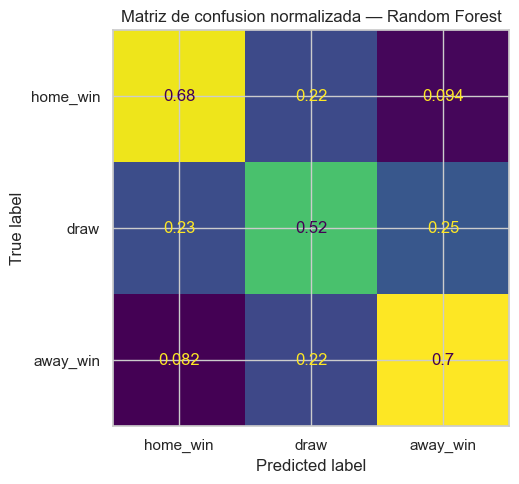

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABEL_NAMES,
    normalize="true",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusion normalizada — Random Forest")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_rf.pdf", bbox_inches="tight")
plt.show()

### 3.6. Accuracy por minuto

Métrica diferencial del trabajo: muestra cómo mejora la predicción conforme avanza el partido.

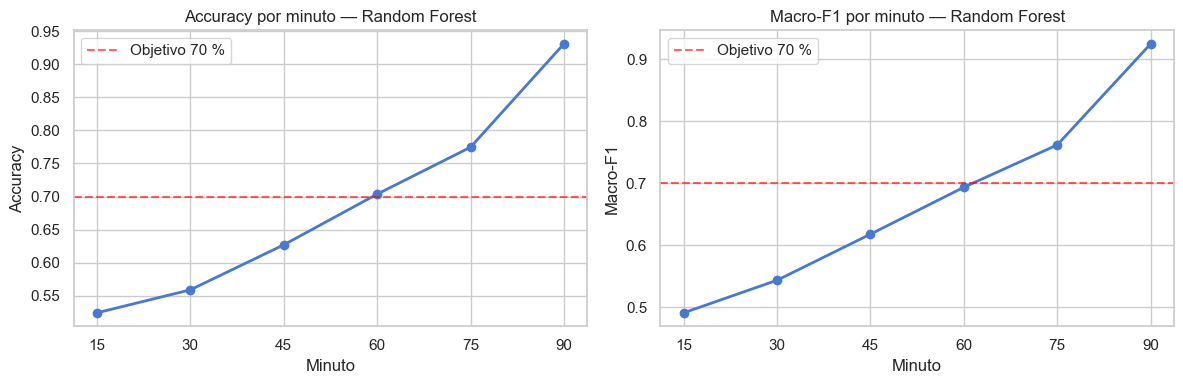

 minute  accuracy  macro_f1  n_samples
     15  0.524566  0.491004        692
     30  0.559249  0.543515        692
     45  0.627168  0.617818        692
     60  0.703757  0.693427        692
     75  0.774566  0.761677        692
     90  0.930636  0.924553        692


In [11]:
CHECKPOINTS = [15, 30, 45, 60, 75, 90]
minute_vals = test["minute"].values

rows = []
for m in CHECKPOINTS:
    mask = minute_vals == m
    rows.append({
        "minute":    m,
        "accuracy":  accuracy_score(y_test[mask], y_pred[mask]),
        "macro_f1":  f1_score(y_test[mask], y_pred[mask], average="macro"),
        "n_samples": int(mask.sum()),
    })

minute_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df["minute"], minute_df[col], marker="o", linewidth=2)
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — Random Forest")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "accuracy_por_minuto_rf.pdf", bbox_inches="tight")
plt.show()

print(minute_df.to_string(index=False))

### 3.7. Importancia de features

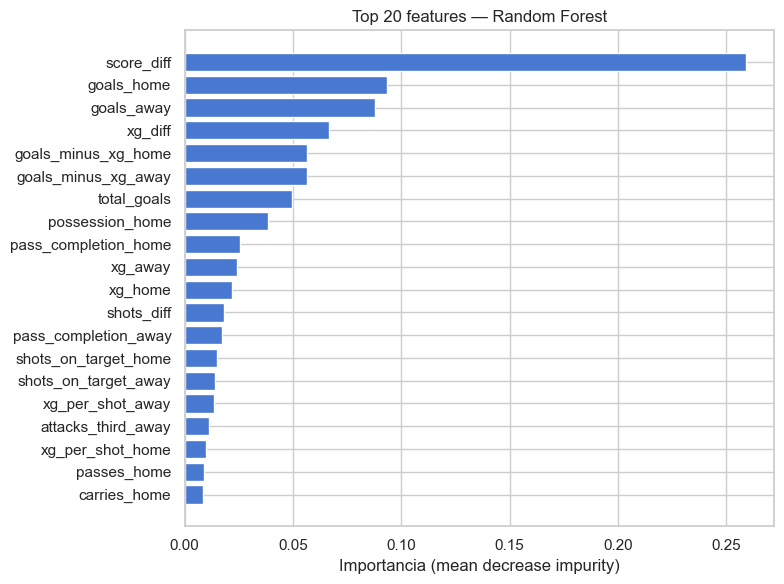

score_diff              0.2590
goals_home              0.0933
goals_away              0.0879
xg_diff                 0.0665
goals_minus_xg_home     0.0567
goals_minus_xg_away     0.0566
total_goals             0.0497
possession_home         0.0383
pass_completion_home    0.0254
xg_away                 0.0243
dtype: float64


In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1])
ax.set_xlabel("Importancia (mean decrease impurity)")
ax.set_title("Top 20 features — Random Forest")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_rf.pdf", bbox_inches="tight")
plt.show()

print(importances.head(10).round(4))

### 3.8. Guardado del modelo

In [13]:
model_path = MODELS_DIR / "random_forest.pkl"
joblib.dump(rf, model_path)
print(f"Modelo guardado en {model_path}")

Modelo guardado en ..\models\random_forest.pkl


## 4. XGBoost

XGBoost se utiliza como segundo modelo basado en árboles. A diferencia de Random Forest, XGBoost construye los árboles de forma secuencial, de manera que cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Antes de entrenar el modelo final, se realiza una búsqueda limitada de hiperparámetros utilizando únicamente el conjunto de entrenamiento. La división interna se realiza a nivel de partido mediante `match_id`, evitando que minutos de un mismo encuentro aparezcan simultáneamente en entrenamiento interno y validación interna.

La selección de la configuración final se realiza mediante el F1-score macro, ya que esta métrica permite valorar el rendimiento de forma equilibrada entre victoria local, empate y victoria visitante.

### 4.1. División interna para XGBoost

In [14]:
# Metadata de partidos del conjunto de entrenamiento
xgb_match_meta = matches[matches["match_id"].isin(train_ids)][["match_id", "final_result"]].copy()

# División interna del train para seleccionar hiperparámetros
# Se divide por partido, no por filas, para evitar fuga de información entre minutos del mismo encuentro.
xgb_fit_ids, xgb_val_ids = train_test_split(
    xgb_match_meta["match_id"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=xgb_match_meta["final_result"]
)

xgb_fit_ids = set(xgb_fit_ids)
xgb_val_ids = set(xgb_val_ids)

xgb_fit_data = train[train["match_id"].isin(xgb_fit_ids)]
xgb_val_data = train[train["match_id"].isin(xgb_val_ids)]

X_xgb_fit = xgb_fit_data[FEATURE_COLS]
y_xgb_fit = xgb_fit_data[TARGET_COL].map(LABEL_MAP)

X_xgb_val = xgb_val_data[FEATURE_COLS]
y_xgb_val = xgb_val_data[TARGET_COL].map(LABEL_MAP)

print(f"XGB fit: {len(xgb_fit_ids):>5} partidos | {len(X_xgb_fit):>7,} filas")
print(f"XGB val: {len(xgb_val_ids):>5} partidos | {len(X_xgb_val):>7,} filas")

XGB fit:  2217 partidos | 199,530 filas
XGB val:   555 partidos |  49,950 filas


### 4.2. Random Search de hiperparámetros

In [16]:
# Se combinan los subconjuntos internos de ajuste y validación
# para que RandomizedSearchCV utilice una partición fija mediante PredefinedSplit.
xgb_tune_data = pd.concat([xgb_fit_data, xgb_val_data], axis=0).copy()

X_xgb_tune = xgb_tune_data[FEATURE_COLS]
y_xgb_tune = xgb_tune_data[TARGET_COL].map(LABEL_MAP)

# PredefinedSplit:
# -1 indica filas utilizadas para entrenar cada configuración
#  0 indica filas utilizadas como validación interna
xgb_test_fold = np.where(
    xgb_tune_data["match_id"].isin(xgb_val_ids),
    0,
    -1
)

xgb_predefined_split = PredefinedSplit(test_fold=xgb_test_fold)

# Pesos de clase para compensar el desbalance.
# Se calculan sobre todo el conjunto de búsqueda, pero durante cada ajuste
# RandomizedSearchCV solo utiliza los pesos correspondientes al fold de entrenamiento.
sample_weights_xgb_tune = compute_sample_weight(
    class_weight="balanced",
    y=y_xgb_tune
)

# Espacio de búsqueda para XGBoost.
# Se incluyen hiperparámetros de complejidad, regularización y submuestreo.
xgb_param_distributions = {
    "n_estimators": [300, 400, 500, 700],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.07, 0.10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5, 8],
    "reg_lambda": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "gamma": [0, 0.1, 0.5, 1],
}

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0,
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_distributions,
    n_iter=12,
    scoring={
        "macro_f1": "f1_macro",
        "accuracy": "accuracy",
        "neg_log_loss": "neg_log_loss"
    },
    refit=False,
    cv=xgb_predefined_split,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=1,
    error_score="raise"
)

xgb_random_search.fit(
    X_xgb_tune,
    y_xgb_tune,
    sample_weight=sample_weights_xgb_tune
)

# Resultados de la búsqueda
xgb_tuning_results_df = pd.DataFrame(xgb_random_search.cv_results_).copy()

xgb_tuning_results_df["logloss_val"] = -xgb_tuning_results_df["mean_test_neg_log_loss"]
xgb_tuning_results_df["macro_f1_val"] = xgb_tuning_results_df["mean_test_macro_f1"]
xgb_tuning_results_df["accuracy_val"] = xgb_tuning_results_df["mean_test_accuracy"]

xgb_tuning_results_df = (
    xgb_tuning_results_df
    .sort_values(["macro_f1_val", "logloss_val"], ascending=[False, True])
    .reset_index(drop=True)
)

cols_to_show = [
    "params",
    "accuracy_val",
    "macro_f1_val",
    "logloss_val",
    "mean_fit_time"
]

print(
    xgb_tuning_results_df[cols_to_show]
    .round({
        "accuracy_val": 4,
        "macro_f1_val": 4,
        "logloss_val": 4,
        "mean_fit_time": 2
    })
    .to_string(index=False)
)

Fitting 1 folds for each of 12 candidates, totalling 12 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=6, min_child_weight=2, n_estimators=400, reg_alpha=0.5, reg_lambda=3, subsample=0.9; total time=  13.4s
[CV] END colsample_bytree=0.8, gamma=1, learning_rate=0.03, max_depth=5, min_child_weight=5, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=  11.2s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=400, reg_alpha=0.1, reg_lambda=10, subsample=0.7; total time=  13.2s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.07, max_depth=5, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=5, subsample=0.9; total time=  11.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=4, min_child_weight=5, n_estimators=400, reg_alpha=0, reg_lambda=3, subsample=1.0; total time=   7.6s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_de

### 4.3. Selección de la mejor configuración

In [17]:
best_xgb_params = xgb_tuning_results_df.iloc[0]["params"].copy()

print("Mejor configuración XGBoost seleccionada por Random Search:")
print(best_xgb_params)

print("\nMétricas en validación interna:")
print(f"Accuracy:  {xgb_tuning_results_df.iloc[0]['accuracy_val']:.4f}")
print(f"Macro-F1:  {xgb_tuning_results_df.iloc[0]['macro_f1_val']:.4f}")
print(f"Log-loss:  {xgb_tuning_results_df.iloc[0]['logloss_val']:.4f}")

Mejor configuración XGBoost seleccionada por Random Search:
{'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.9}

Métricas en validación interna:
Accuracy:  0.6220
Macro-F1:  0.6197
Log-loss:  0.7832


### 4.4. Entrenamiento final

In [18]:
sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_model = XGBClassifier(
    **best_xgb_params,
    importance_type="gain",
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0,
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

print("Entrenamiento final de XGBoost completado.")

Entrenamiento final de XGBoost completado.


### 4.5. Métricas de evaluacion

In [19]:
y_pred_xgb      = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)

acc_xgb      = accuracy_score(y_test, y_pred_xgb)
macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
logloss_xgb  = log_loss(y_test, y_pred_prob_xgb)

print(f"Accuracy:  {acc_xgb:.4f}  (objetivo >= 0.70)")
print(f"Macro-F1:  {macro_f1_xgb:.4f}")
print(f"Log-loss:  {logloss_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=LABEL_NAMES))

Accuracy:  0.6539  (objetivo >= 0.70)
Macro-F1:  0.6265
Log-loss:  0.7531

              precision    recall  f1-score   support

    home_win       0.77      0.72      0.74     26730
        draw       0.46      0.44      0.45     15120
    away_win       0.66      0.72      0.69     20430

    accuracy                           0.65     62280
   macro avg       0.63      0.63      0.63     62280
weighted avg       0.65      0.65      0.65     62280



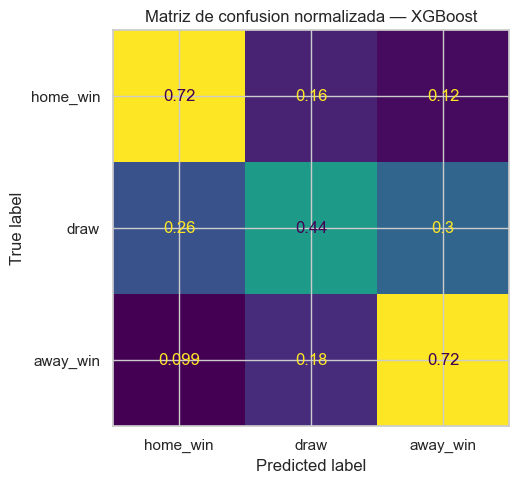

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=LABEL_NAMES,
    normalize="true",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusion normalizada — XGBoost")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_xgb.pdf", bbox_inches="tight")
plt.show()

### 4.6. Accuracy por minuto

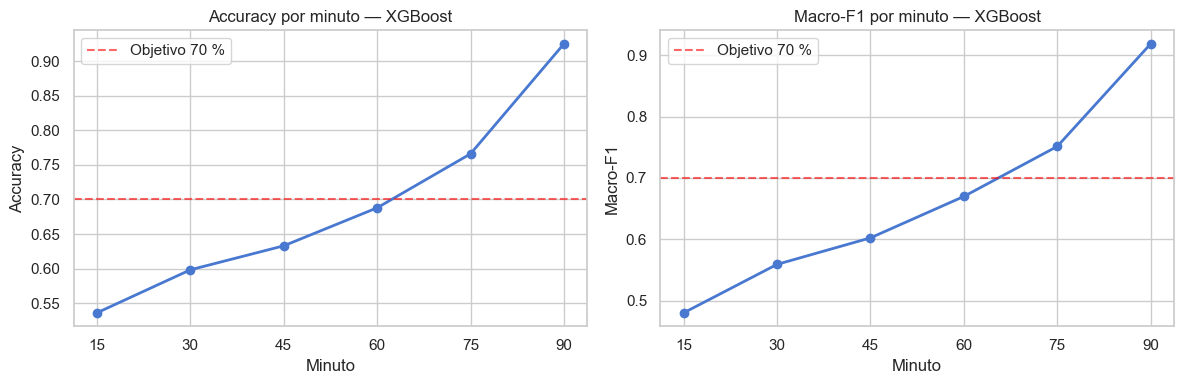

 minute  accuracy  macro_f1  n_samples
     15  0.536127  0.480672        692
     30  0.598266  0.559488        692
     45  0.632948  0.602590        692
     60  0.687861  0.669988        692
     75  0.765896  0.751347        692
     90  0.924855  0.918176        692


In [21]:
rows_xgb = []
for m in CHECKPOINTS:
    mask = minute_vals == m
    rows_xgb.append({
        "minute":    m,
        "accuracy":  accuracy_score(y_test[mask], y_pred_xgb[mask]),
        "macro_f1":  f1_score(y_test[mask], y_pred_xgb[mask], average="macro"),
        "n_samples": int(mask.sum()),
    })

minute_df_xgb = pd.DataFrame(rows_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df_xgb["minute"], minute_df_xgb[col], marker="o", linewidth=2)
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — XGBoost")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "accuracy_por_minuto_xgb.pdf", bbox_inches="tight")
plt.show()

print(minute_df_xgb.to_string(index=False))

### 4.7. Importancia de features

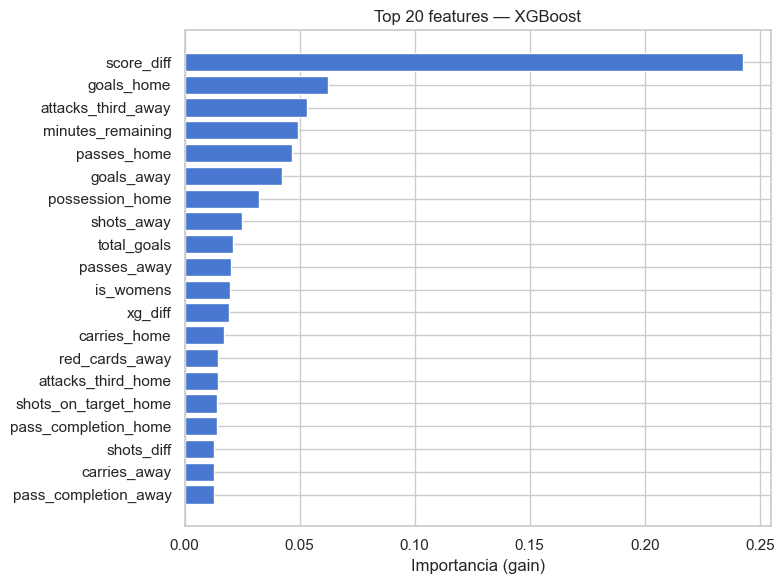

score_diff            0.2425
goals_home            0.0625
attacks_third_away    0.0534
minutes_remaining     0.0494
passes_home           0.0466
goals_away            0.0422
possession_home       0.0322
shots_away            0.0251
total_goals           0.0212
passes_away           0.0202
dtype: float32


In [22]:
importances_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20_xgb = importances_xgb.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_xgb.index[::-1], top20_xgb.values[::-1])
ax.set_xlabel("Importancia (gain)")
ax.set_title("Top 20 features — XGBoost")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_xgb.pdf", bbox_inches="tight")
plt.show()

print(importances_xgb.head(10).round(4))

### 4.8. Guardado del modelo

In [23]:
model_path_xgb = MODELS_DIR / "xgboost.pkl"
joblib.dump(xgb_model, model_path_xgb)
print(f"Modelo guardado en {model_path_xgb}")

Modelo guardado en ..\models\xgboost.pkl


## 5. SVM lineal

Se evalúa un modelo SVM lineal como alternativa a los modelos ensemble.
A diferencia de un SVC con kernel RBF, LinearSVC es más adecuado para datasets grandes.
Además, se aplica StandardScaler porque los SVM son sensibles a la escala de las variables.
La búsqueda del hiperparámetro C se realiza sobre una partición interna de validación,
respetando siempre la separación por partido para evitar fuga de información.

### 5.1. División interna para ajuste, validación y calibración

In [24]:
# Metadata de partidos del conjunto de entrenamiento
train_match_meta = matches[matches["match_id"].isin(train_ids)][["match_id", "final_result"]].copy()

# Primera división: ajuste inicial y conjunto temporal para validación/calibración
svm_fit_ids, svm_temp_ids = train_test_split(
    train_match_meta["match_id"],
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=train_match_meta["final_result"]
)

svm_temp_meta = train_match_meta[train_match_meta["match_id"].isin(svm_temp_ids)]

# Segunda división: validación para escoger C y calibración para obtener probabilidades
svm_val_ids, svm_calib_ids = train_test_split(
    svm_temp_meta["match_id"],
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=svm_temp_meta["final_result"]
)

svm_fit_ids = set(svm_fit_ids)
svm_val_ids = set(svm_val_ids)
svm_calib_ids = set(svm_calib_ids)

svm_fit_data = train[train["match_id"].isin(svm_fit_ids)]
svm_val_data = train[train["match_id"].isin(svm_val_ids)]
svm_calib_data = train[train["match_id"].isin(svm_calib_ids)]

X_svm_fit = svm_fit_data[FEATURE_COLS]
y_svm_fit = svm_fit_data[TARGET_COL].map(LABEL_MAP)

X_svm_val = svm_val_data[FEATURE_COLS]
y_svm_val = svm_val_data[TARGET_COL].map(LABEL_MAP)

X_svm_calib = svm_calib_data[FEATURE_COLS]
y_svm_calib = svm_calib_data[TARGET_COL].map(LABEL_MAP)

print(f"SVM fit:   {len(svm_fit_ids):>5} partidos | {len(X_svm_fit):>7,} filas")
print(f"SVM val:   {len(svm_val_ids):>5} partidos | {len(X_svm_val):>7,} filas")
print(f"SVM calib: {len(svm_calib_ids):>5} partidos | {len(X_svm_calib):>7,} filas")

SVM fit:    1940 partidos | 174,600 filas
SVM val:     416 partidos |  37,440 filas
SVM calib:   416 partidos |  37,440 filas


Esta división interna solo afecta al conjunto de entrenamiento. El conjunto de test se mantiene intacto y será el mismo que en Random Forest y XGBoost. Se separan partidos completos para evitar que minutos de un mismo partido aparezcan en particiones distintas.

### 5.2. Búsqueda del parámetro C

In [25]:
C_VALUES = [0.01, 0.1, 1, 10, 100]

svm_results = []
svm_candidates = {}

for C in C_VALUES:
    svm_candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(
            C=C,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=20000,
            dual=False
        ))
    ])

    svm_candidate.fit(X_svm_fit, y_svm_fit)

    y_val_pred = svm_candidate.predict(X_svm_val)

    val_acc = accuracy_score(y_svm_val, y_val_pred)
    val_macro_f1 = f1_score(y_svm_val, y_val_pred, average="macro")

    svm_results.append({
        "C": C,
        "accuracy_val": val_acc,
        "macro_f1_val": val_macro_f1
    })

    svm_candidates[C] = svm_candidate

svm_results_df = pd.DataFrame(svm_results).sort_values("macro_f1_val", ascending=False)

print(svm_results_df.round(4).to_string(index=False))

     C  accuracy_val  macro_f1_val
  0.01        0.6555        0.5667
  0.10        0.6553        0.5665
100.00        0.6552        0.5665
 10.00        0.6552        0.5664
  1.00        0.6552        0.5664


### 5.3. Selección del mejor valor de C

Se selecciona C usando Macro-F1, ya que esta métrica penaliza mejor el mal rendimiento en clases minoritarias como el empate.

In [26]:
best_C = svm_results_df.iloc[0]["C"]

print(f"Mejor C seleccionado según Macro-F1 de validación: {best_C}")

Mejor C seleccionado según Macro-F1 de validación: 0.01


### 5.4. Entrenamiento final del modelo

Una vez seleccionado C, se reentrena el SVM con fit + validación. El subconjunto de calibración se reserva para ajustar las probabilidades.

In [27]:
# Reentrenamos el modelo con el mejor C usando fit + validación
svm_train_final_ids = svm_fit_ids.union(svm_val_ids)
svm_train_final_data = train[train["match_id"].isin(svm_train_final_ids)]

X_svm_train_final = svm_train_final_data[FEATURE_COLS]
y_svm_train_final = svm_train_final_data[TARGET_COL].map(LABEL_MAP)

svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=best_C,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=20000,
        dual=False
    ))
])

svm_base.fit(X_svm_train_final, y_svm_train_final)

print("Entrenamiento final del SVM completado.")

Entrenamiento final del SVM completado.


### 5.5. Calibración de probabilidades

In [28]:
# LinearSVC no proporciona predict_proba directamente.
# Por eso se calibra el modelo usando un subconjunto de entrenamiento no usado para ajustar el modelo final.
# Esto permite calcular log-loss y comparar el SVM con Random Forest y XGBoost.

if FrozenEstimator is not None:
    svm_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(svm_base),
        method="sigmoid"
    )
else:
    svm_model = CalibratedClassifierCV(
        estimator=svm_base,
        method="sigmoid",
        cv="prefit"
    )

svm_model.fit(X_svm_calib, y_svm_calib)

print("Calibración del SVM completada.")

Calibración del SVM completada.


La calibración es necesaria para obtener predict_proba. Sin esta calibración, el SVM podría evaluarse con accuracy y Macro-F1, pero no con log-loss.

### 5.6. Métricas de evaluación

In [29]:
y_pred_svm = svm_model.predict(X_test)
y_pred_prob_svm = svm_model.predict_proba(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
macro_f1_svm = f1_score(y_test, y_pred_svm, average="macro")
logloss_svm = log_loss(y_test, y_pred_prob_svm)

print(f"Accuracy:  {acc_svm:.4f}  (objetivo >= 0.70)")
print(f"Macro-F1:  {macro_f1_svm:.4f}")
print(f"Log-loss:  {logloss_svm:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=LABEL_NAMES))

Accuracy:  0.6387  (objetivo >= 0.70)
Macro-F1:  0.4999
Log-loss:  0.7977

              precision    recall  f1-score   support

    home_win       0.65      0.87      0.75     26730
        draw       0.65      0.03      0.06     15120
    away_win       0.62      0.78      0.69     20430

    accuracy                           0.64     62280
   macro avg       0.64      0.56      0.50     62280
weighted avg       0.64      0.64      0.56     62280



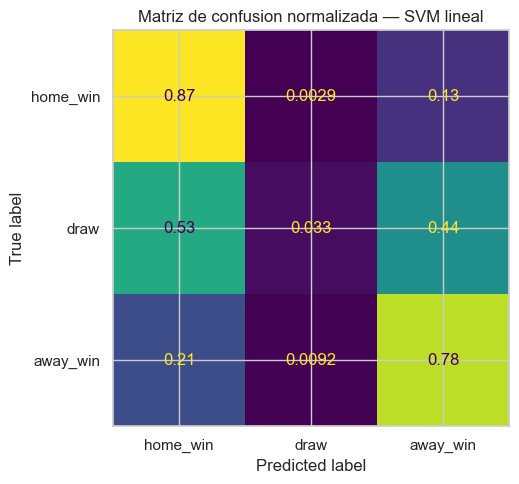

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=LABEL_NAMES,
    normalize="true",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusion normalizada — SVM lineal")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_svm.pdf", bbox_inches="tight")
plt.show()

### 5.7. Accuracy por minuto

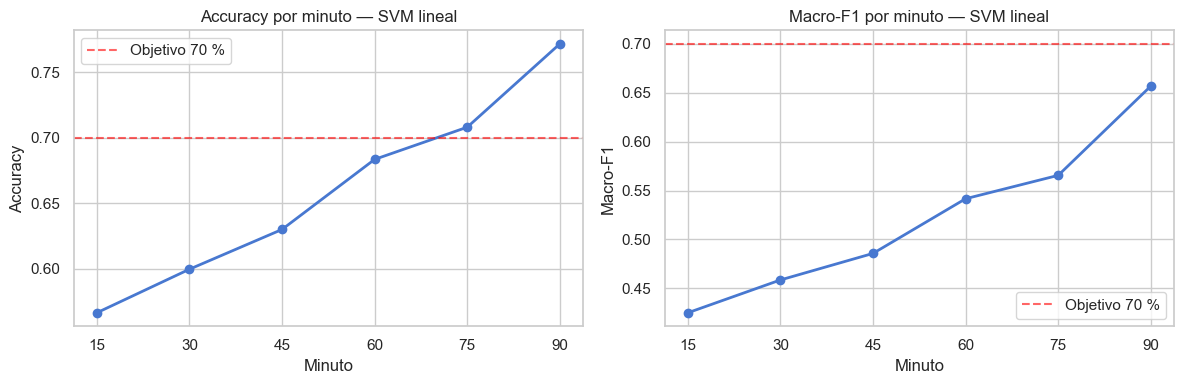

 minute  accuracy  macro_f1  n_samples
     15  0.566474  0.425004        692
     30  0.599711  0.458579        692
     45  0.630058  0.485729        692
     60  0.683526  0.541642        692
     75  0.708092  0.565555        692
     90  0.771676  0.656864        692


In [31]:
rows_svm = []

for m in CHECKPOINTS:
    mask = minute_vals == m
    rows_svm.append({
        "minute": m,
        "accuracy": accuracy_score(y_test[mask], y_pred_svm[mask]),
        "macro_f1": f1_score(y_test[mask], y_pred_svm[mask], average="macro"),
        "n_samples": int(mask.sum()),
    })

minute_df_svm = pd.DataFrame(rows_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df_svm["minute"], minute_df_svm[col], marker="o", linewidth=2)
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — SVM lineal")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "accuracy_por_minuto_svm.pdf", bbox_inches="tight")
plt.show()

print(minute_df_svm.to_string(index=False))

### 5.8. Coeficientes del modelo

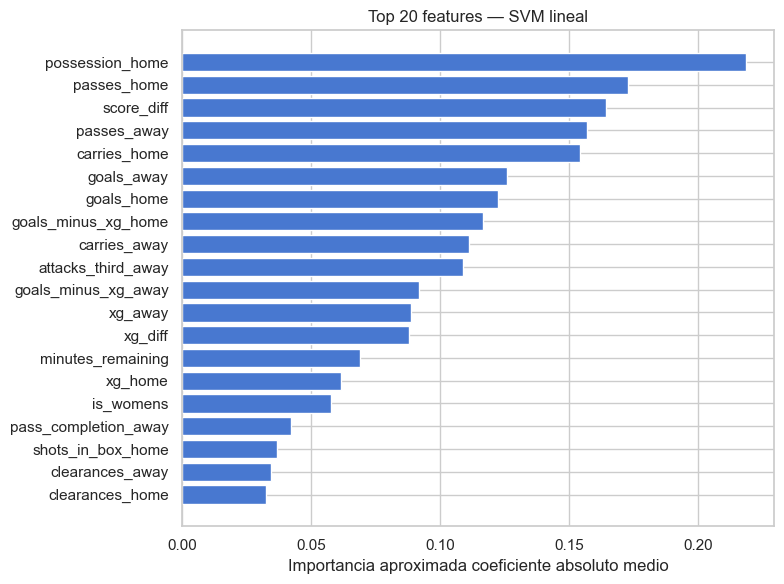

possession_home        0.2185
passes_home            0.1729
score_diff             0.1645
passes_away            0.1569
carries_home           0.1541
goals_away             0.1260
goals_home             0.1225
goals_minus_xg_home    0.1166
carries_away           0.1114
attacks_third_away     0.1089
dtype: float64


In [32]:
coef = svm_base.named_steps["svm"].coef_

coef_importance = pd.Series(
    np.mean(np.abs(coef), axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

top20_svm = coef_importance.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_svm.index[::-1], top20_svm.values[::-1])
ax.set_xlabel("Importancia aproximada coeficiente absoluto medio")
ax.set_title("Top 20 features — SVM lineal")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_svm.pdf", bbox_inches="tight")
plt.show()

print(coef_importance.head(10).round(4))

En SVM lineal, los coeficientes permiten una interpretación aproximada de la influencia de cada variable, pero no son directamente comparables con la importancia de variables de Random Forest o XGBoost.

### 5.9. Guardado del modelo

In [33]:
model_path_svm = MODELS_DIR / "svm_linear_calibrated.pkl"
joblib.dump(svm_model, model_path_svm)
print(f"Modelo guardado en {model_path_svm}")

Modelo guardado en ..\models\svm_linear_calibrated.pkl


## 6. Interpretabilidad complementaria

Además de las importancias internas de variables y los coeficientes del SVM, se incorpora un análisis complementario de interpretabilidad mediante Permutation Importance y ejemplos concretos de predicción individual. Este análisis permite valorar qué variables afectan más al rendimiento del modelo y cómo se comporta cada modelo en casos específicos del conjunto de test.

In [34]:
# Muestra común para interpretabilidad
# Se utiliza una muestra del conjunto de test para reducir el coste computacional
# y aplicar el mismo criterio de comparación a los tres modelos.

INTERPRET_N = 3000

interpret_data = test.sample(
    n=min(INTERPRET_N, len(test)),
    random_state=RANDOM_STATE
).copy()

X_interpret = interpret_data[FEATURE_COLS]
y_interpret = interpret_data[TARGET_COL].map(LABEL_MAP)

print(f"Muestra de interpretabilidad: {len(X_interpret):,} filas")
print(f"Partidos incluidos: {interpret_data['match_id'].nunique():,}")

Muestra de interpretabilidad: 3,000 filas
Partidos incluidos: 687


In [35]:
def compute_and_plot_permutation_importance(
    model,
    model_name,
    X,
    y,
    file_name,
    n_repeats=5,
    top_n=15
):
    """
    Calcula y grafica Permutation Importance usando Macro-F1 como métrica.
    La importancia representa cuánto baja el rendimiento al permutar cada variable.
    """

    print(f"Calculando Permutation Importance para {model_name}...")

    result = permutation_importance(
        model,
        X,
        y,
        scoring="f1_macro",
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(perm_df.head(top_n))

    top_perm = perm_df.head(top_n).sort_values("importance_mean")

    plt.figure(figsize=(8, 6))
    plt.barh(top_perm["feature"], top_perm["importance_mean"])
    plt.xlabel("Disminución media del Macro-F1 al permutar la variable")
    plt.title(f"Permutation Importance - {model_name}")
    plt.tight_layout()

    path = FIGS_DIR / file_name
    plt.savefig(path, bbox_inches="tight")
    plt.show()

    print(f"Figura guardada en: {path}")

    return perm_df

### 6.1. Permutation Importance - Random Forest

Calculando Permutation Importance para Random Forest...


,feature,importance_mean,importance_std
34,score_diff,0.063185,0.004456
37,possession_home,0.008587,0.004343
17,goals_away,0.007885,0.003543
42,total_goals,0.004700,0.001118
39,pass_completion_away,0.004583,0.002150
46,goals_minus_xg_away,0.004002,0.003421
0,goals_home,0.003388,0.002440
18,shots_away,0.002157,0.001522
30,xg_away,0.001694,0.002024
29,attacks_third_away,0.001489,0.001055


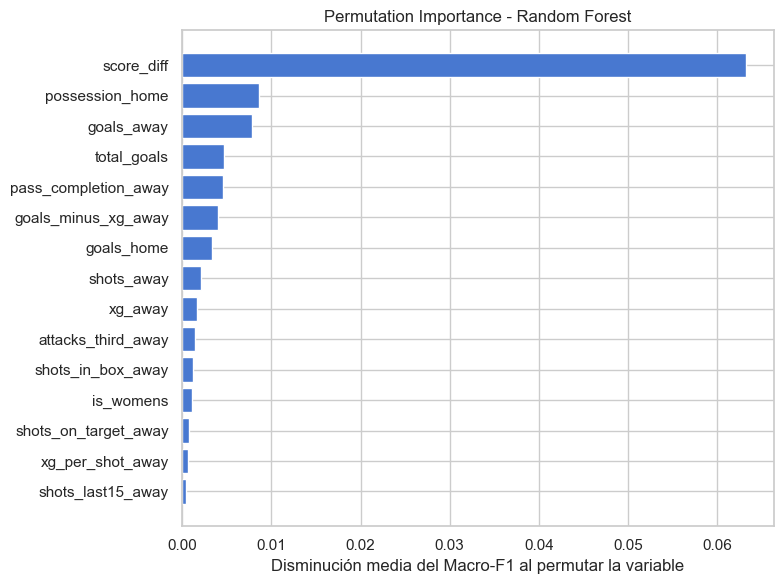

Figura guardada en: ..\assets\figuras\modeling\permutation_importance_rf.pdf


In [36]:
perm_rf = compute_and_plot_permutation_importance(
    model=rf,
    model_name="Random Forest",
    X=X_interpret,
    y=y_interpret,
    file_name="permutation_importance_rf.pdf",
    n_repeats=5,
    top_n=15
)

### 6.2. Permutation Importance - XGBoost

Calculando Permutation Importance para XGBoost...


,feature,importance_mean,importance_std
34,score_diff,0.191778,0.003237
37,possession_home,0.019007,0.002310
29,attacks_third_away,0.016655,0.002272
47,is_womens,0.012594,0.004819
39,pass_completion_away,0.012259,0.001280
12,attacks_third_home,0.007989,0.003833
46,goals_minus_xg_away,0.006215,0.002337
44,xg_per_shot_away,0.005596,0.000872
45,goals_minus_xg_home,0.005260,0.003692
40,minutes_remaining,0.005232,0.002116


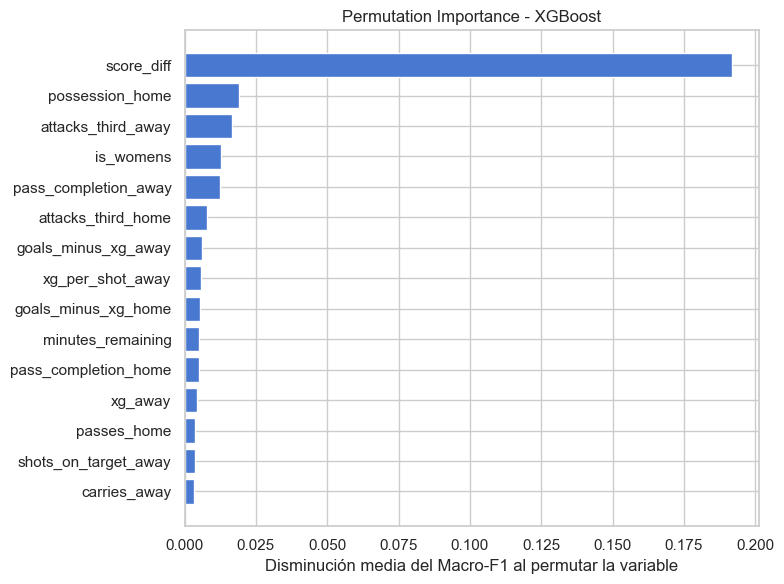

Figura guardada en: ..\assets\figuras\modeling\permutation_importance_xgb.pdf


In [37]:
perm_xgb = compute_and_plot_permutation_importance(
    model=xgb_model,
    model_name="XGBoost",
    X=X_interpret,
    y=y_interpret,
    file_name="permutation_importance_xgb.pdf",
    n_repeats=5,
    top_n=15
)

### 6.3. Permutation Importance - SVM lineal

Calculando Permutation Importance para SVM lineal...


,feature,importance_mean,importance_std
37,possession_home,0.056117,0.006695
29,attacks_third_away,0.025118,0.003142
34,score_diff,0.024753,0.003918
45,goals_minus_xg_home,0.019872,0.003983
17,goals_away,0.015875,0.003126
46,goals_minus_xg_away,0.015078,0.003884
0,goals_home,0.014957,0.003417
35,xg_diff,0.012936,0.002892
30,xg_away,0.006616,0.003387
26,carries_away,0.004589,0.003292


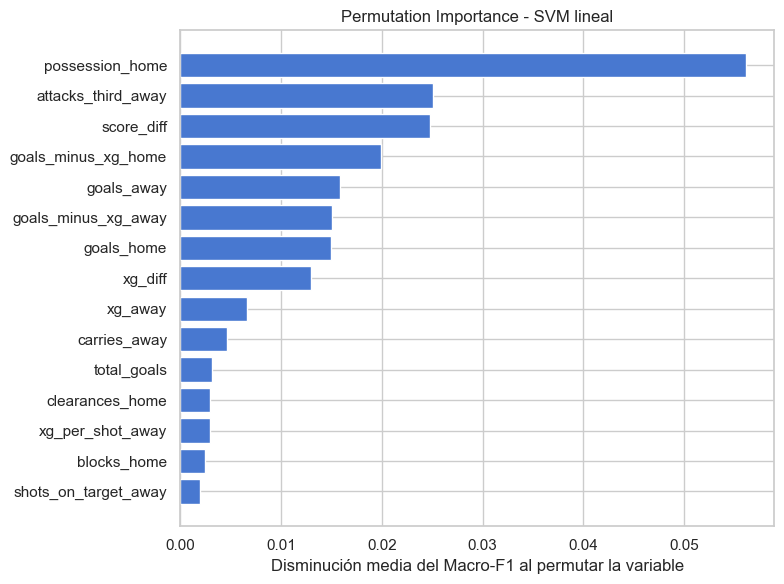

Figura guardada en: ..\assets\figuras\modeling\permutation_importance_svm.pdf


In [38]:
perm_svm = compute_and_plot_permutation_importance(
    model=svm_model,
    model_name="SVM lineal",
    X=X_interpret,
    y=y_interpret,
    file_name="permutation_importance_svm.pdf",
    n_repeats=5,
    top_n=15
)

In [44]:
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

EXAMPLE_FEATURES = [
    "score_diff",
    "goals_home",
    "goals_away",
    "xg_diff",
    "shots_diff",
    "possession_home",
    "total_goals",
    "minutes_remaining",
    "players_diff"
]

TARGET_EXAMPLE_MINUTES = [30, 60, 90]


def evaluate_random_matches_for_all_models(
    models,
    test_data,
    n_matches=3,
    target_minutes=TARGET_EXAMPLE_MINUTES,
    random_state=RANDOM_STATE
):
    """
    Selecciona n partidos aleatorios del conjunto de test y evalúa todos los modelos
    en los mismos partidos y en los mismos minutos.

    Para cada partido y minuto:
    - obtiene probabilidades de cada modelo;
    - calcula la clase predicha;
    - compara la predicción con el resultado final real del partido.
    """

    # Nos quedamos solo con partidos que tengan todos los minutos requeridos
    candidate_data = test_data[test_data["minute"].isin(target_minutes)].copy()

    valid_match_ids = (
        candidate_data
        .groupby("match_id")["minute"]
        .apply(lambda x: set(target_minutes).issubset(set(x)))
    )

    valid_match_ids = valid_match_ids[valid_match_ids].index.to_list()

    rng = np.random.default_rng(random_state)

    selected_match_ids = rng.choice(
        valid_match_ids,
        size=n_matches,
        replace=False
    )

    selected_data = (
        candidate_data[candidate_data["match_id"].isin(selected_match_ids)]
        .copy()
        .sort_values(["match_id", "minute"])
        .reset_index(drop=True)
    )

    # Tabla con el estado del partido en cada minuto.
    available_features = [
        f for f in EXAMPLE_FEATURES
        if f in selected_data.columns
    ]

    state_table = selected_data[
        ["match_id", "minute", TARGET_COL, *available_features]
    ].copy()

    prediction_rows = []

    for model_name, model in models.items():
        X_selected = selected_data[FEATURE_COLS]

        preds = model.predict(X_selected)
        probs = model.predict_proba(X_selected)

        for i, row in selected_data.iterrows():
            pred_label = INV_LABEL_MAP[preds[i]]
            true_label = row[TARGET_COL]

            prediction_rows.append({
                "model": model_name,
                "match_id": row["match_id"],
                "minute": row["minute"],
                "final_result": true_label,
                "pred_label": pred_label,
                "correct": pred_label == true_label,
                "p_home_win": probs[i][LABEL_MAP["home_win"]],
                "p_draw": probs[i][LABEL_MAP["draw"]],
                "p_away_win": probs[i][LABEL_MAP["away_win"]],
            })

    predictions_table = pd.DataFrame(prediction_rows)

    predictions_table = predictions_table.sort_values(
        ["match_id", "minute", "model"]
    ).reset_index(drop=True)

    # Resumen de aciertos por modelo en los ejemplos seleccionados
    accuracy_summary = (
        predictions_table
        .groupby("model")["correct"]
        .agg(["sum", "count", "mean"])
        .rename(columns={
            "sum": "aciertos",
            "count": "total_predicciones",
            "mean": "accuracy_ejemplos"
        })
        .reset_index()
    )

    # Resumen por partido y modelo para ver si acierta en cada minuto
    match_model_summary = (
        predictions_table
        .pivot_table(
            index=["match_id", "final_result", "model"],
            columns="minute",
            values="correct",
            aggfunc="first"
        )
        .reset_index()
    )

    match_model_summary.columns.name = None

    print("=" * 90)
    print("Partidos aleatorios seleccionados para análisis individual")
    print("=" * 90)

    display(
        selected_data[["match_id", TARGET_COL]]
        .drop_duplicates()
        .rename(columns={TARGET_COL: "final_result"})
        .reset_index(drop=True)
    )

    print("\nEstado del partido en los minutos analizados:")
    display(state_table)

    print("\nPredicciones y probabilidades por modelo:")
    display(predictions_table)

    print("\nResumen de aciertos por modelo:")
    display(accuracy_summary)

    print("\nAciertos por partido, modelo y minuto:")
    display(match_model_summary)

    return {
        "selected_match_ids": selected_match_ids,
        "state_table": state_table,
        "predictions_table": predictions_table,
        "accuracy_summary": accuracy_summary,
        "match_model_summary": match_model_summary
    }

### 6.4. Ejemplos concretos de predicción individual

In [45]:
models_for_examples = {
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "SVM lineal": svm_model
}

examples_all_models = evaluate_random_matches_for_all_models(
    models=models_for_examples,
    test_data=test,
    n_matches=3,
    target_minutes=[30, 60, 90],
    random_state=RANDOM_STATE
)

Partidos aleatorios seleccionados para análisis individual


,match_id,final_result
0,3775617,home_win
1,3893811,home_win
2,3920392,home_win



Estado del partido en los minutos analizados:


,match_id,minute,final_result,score_diff,goals_home,goals_away,xg_diff,shots_diff,possession_home,total_goals,minutes_remaining,players_diff
0,3775617,30,home_win,1.0,1.0,0.0,0.777609,1.0,0.329897,1.0,60,0.0
1,3775617,60,home_win,1.0,1.0,0.0,0.110264,-4.0,0.299479,1.0,30,0.0
2,3775617,90,home_win,1.0,1.0,0.0,-0.227711,-8.0,0.298791,1.0,0,0.0
3,3893811,30,home_win,1.0,1.0,0.0,0.382862,3.0,0.873984,1.0,60,0.0
4,3893811,60,home_win,1.0,1.0,0.0,0.454912,4.0,0.828092,1.0,30,0.0
5,3893811,90,home_win,1.0,1.0,0.0,0.493220,6.0,0.769912,1.0,0,0.0
6,3920392,30,home_win,0.0,0.0,0.0,-0.063786,-2.0,0.619048,0.0,60,0.0
7,3920392,60,home_win,0.0,0.0,0.0,-0.075006,0.0,0.600000,0.0,30,0.0
8,3920392,90,home_win,1.0,1.0,0.0,0.621002,2.0,0.634064,1.0,0,0.0



Predicciones y probabilidades por modelo:


,model,match_id,minute,final_result,pred_label,correct,p_home_win,p_draw,p_away_win
0,Random Forest,3775617,30,home_win,home_win,True,0.456429,0.354635,0.188936
1,SVM lineal,3775617,30,home_win,home_win,True,0.617367,0.170494,0.212139
2,XGBoost,3775617,30,home_win,home_win,True,0.431181,0.333364,0.235455
3,Random Forest,3775617,60,home_win,home_win,True,0.417838,0.380227,0.201936
4,SVM lineal,3775617,60,home_win,home_win,True,0.574539,0.259006,0.166455
5,XGBoost,3775617,60,home_win,draw,False,0.329021,0.361114,0.309865
6,Random Forest,3775617,90,home_win,home_win,True,0.470140,0.380227,0.149632
7,SVM lineal,3775617,90,home_win,home_win,True,0.493130,0.339508,0.167362
8,XGBoost,3775617,90,home_win,home_win,True,0.617939,0.328379,0.053683
9,Random Forest,3893811,30,home_win,home_win,True,0.741082,0.193241,0.065676



Resumen de aciertos por modelo:


,model,aciertos,total_predicciones,accuracy_ejemplos
0,Random Forest,7,9,0.777778
1,SVM lineal,9,9,1.000000
2,XGBoost,6,9,0.666667



Aciertos por partido, modelo y minuto:


,match_id,final_result,model,30,60,90
0,3775617,home_win,Random Forest,True,True,True
1,3775617,home_win,SVM lineal,True,True,True
2,3775617,home_win,XGBoost,True,False,True
3,3893811,home_win,Random Forest,True,True,True
4,3893811,home_win,SVM lineal,True,True,True
5,3893811,home_win,XGBoost,True,True,True
6,3920392,home_win,Random Forest,False,False,True
7,3920392,home_win,SVM lineal,True,True,True
8,3920392,home_win,XGBoost,False,False,True


## 7. Comparación de modelos

               Accuracy  Macro-F1  Log-loss
Modelo                                     
Random Forest    0.6503    0.6333    0.7718
XGBoost          0.6539    0.6265    0.7531
SVM lineal       0.6387    0.4999    0.7977


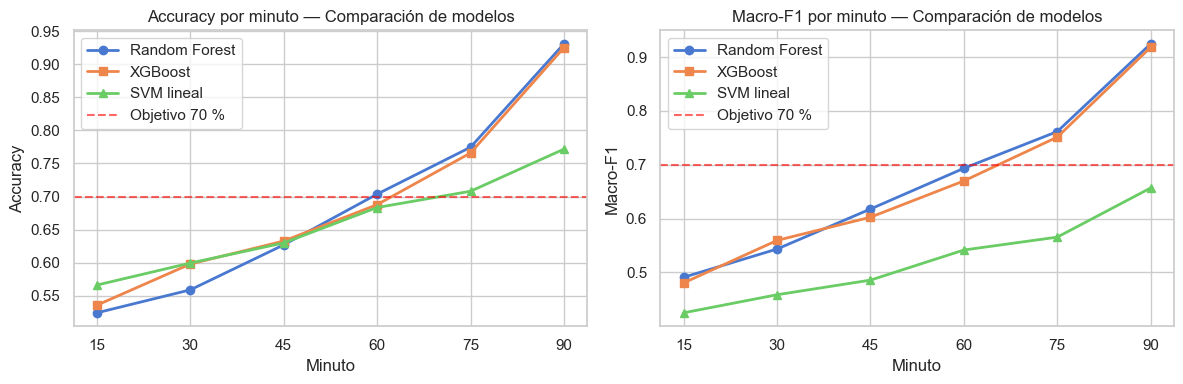

In [41]:
comparison = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost", "SVM lineal"],
    "Accuracy": [acc, acc_xgb, acc_svm],
    "Macro-F1": [macro_f1, macro_f1_xgb, macro_f1_svm],
    "Log-loss": [logloss, logloss_xgb, logloss_svm],
}).set_index("Modelo")

print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df["minute"], minute_df[col], marker="o", linewidth=2, label="Random Forest")
    ax.plot(minute_df_xgb["minute"], minute_df_xgb[col], marker="s", linewidth=2, label="XGBoost")
    ax.plot(minute_df_svm["minute"], minute_df_svm[col], marker="^", linewidth=2, label="SVM lineal")
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — Comparación de modelos")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "comparison_rf_xgb_svm.pdf", bbox_inches="tight")
plt.show()